# **Assemble Data**

In [43]:
from datasets import load_dataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

In [2]:
ds = load_dataset("imdb")

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [4]:
train_df = ds['train'].to_pandas()

In [5]:
train_df.sample(10)

,text,label
13730,The arrival of vast waves of white settlers in...,1
4259,"I'm not usually given to hyperbole, but after ...",0
23381,This Filmfour funded Sci-Fi movie is most defi...,1
11736,"A yawn-inducing, snail-paced disappointment, I...",0
20366,The Write Word<br /><br />What you see is what...,1
8082,One of the most boring slashers ever.. If you ...,0
17509,"don't mind the soundtrack, which is played out...",1
20502,This is by far one of the better made movies a...,1
18195,What do you do with a 14-inch cocked porn star...,1
13129,"A wonderful film by Powell and Pressburger, wh...",1


In [6]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [7]:
train_df['sentiment']=np.where(train_df.label==1,"positive", "negative")

In [8]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [9]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

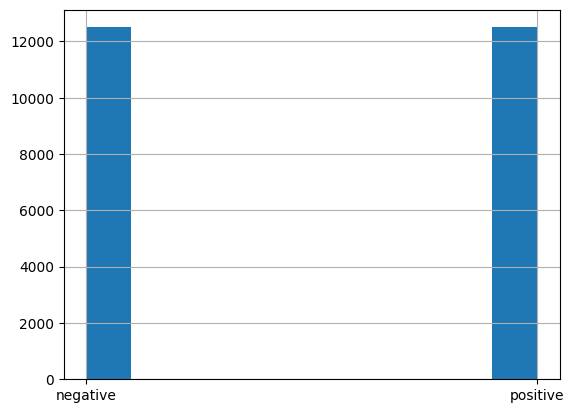

In [10]:
train_df.sentiment.hist()

In [12]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

In [13]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [15]:
columns = ['text', 'sentiment']
gold_examples = (gold_examples_df[columns]
                 .sample(20, random_state=34)
                 .to_json(orient='records')
                 )

In [17]:
import json

In [19]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

In [20]:
user_message_template = """```{movie_review}```"""

In [21]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as
'positive' or 'negative'Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""
zero_shot_prompt = [{'role':'system', 'content':
zero_shot_system_message}]

In [22]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as
'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [23]:
positive_reviews = (examples_df.sentiment == 'positive')
negative_reviews = (examples_df.sentiment == 'negative')

In [24]:
(positive_reviews.shape, negative_reviews.shape)

((20000,), (20000,))

In [25]:
columns = ['text', 'sentiment']
positive_examples = examples_df.loc[positive_reviews,
columns].sample(4)
negative_examples = examples_df.loc[negative_reviews,
columns].sample(4)

In [26]:
positive_examples

,text,sentiment
16521,The movie starts out with a bunch of Dead Men ...,positive
13711,Origins of the Care Bears & their Cousins. If ...,positive
17171,I saw Brother's Shadow at the Tribeca Film Fes...,positive
14500,I don't understand why the reviews of this fil...,positive


In [27]:
negative_examples

,text,sentiment
5079,This movie was in a sci-fi 50-pack a friend of...,negative
5283,***SPOILER ALERT***<br /><br />I love Tim Roth...,negative
6133,*review may contain spoilers*<br /><br />predi...,negative
3022,I thought that Zombie Flesh Eaters 2 was quite...,negative


In [31]:
def create_examples(dataset, n=4):
    positive_reviews = (dataset.sentiment == 'positive')
    negative_reviews = (dataset.sentiment == 'negative')
    columns_to_select = ['text', 'sentiment']
    positive_examples = dataset.loc[positive_reviews,
columns_to_select].sample(n)
    negative_examples = dataset.loc[negative_reviews,
columns_to_select].sample(n)
    examples = pd.concat([positive_examples, negative_examples])
    # sampling without replacement is equivalent to random shuffling
    randomized_examples = examples.sample(2*n, replace=False)
    return randomized_examples.to_json(orient='records')


examples = create_examples(examples_df, 2)
json.loads(examples)

[{'text': "This movie is about as underrated as Police Acadmey Mission to Moscow. This movie is never funny. It's maybe the worst comedy spoof ever made. Very boring,and dumb beyond belief. For those people that think this movie is underrated god help you. I give this movie * out of ****<br /><br />",
  'sentiment': 'negative'},
 {'text': 'Was this a comedy or was it a drama? I begin this review by asking this question because the film that I just witnessed, Hollywood Shuffle, was neither funny or rather dramatic. While it tried so hard to make a point, because of this lack of definition (comedy or drama), the clever themes and pointed remarks were lost. While I am a strong believer that there is too much racial profiling happening in Hollywood, even today, I do not believe that Townsend\'s directorial debut did much to stop it. Instead, I feel it only added more fuel to the fire. Townsend\'s comic timing in this film was disastrous due to the fact that the elements he was supposed to 

In [32]:
def create_prompt(system_message, examples, user_message_template):
    few_shot_prompt = [{'role':'system', 'content': system_message}]
    for example in json.loads(examples):
        example_review = example['text']
        example_sentiment = example['sentiment']
        few_shot_prompt.append(
        {
            'role': 'user',
            'content': user_message_template.format(
                movie_review=example_review
            )
        }
    )
    few_shot_prompt.append(
        {'role': 'assistant', 'content': f"{example_sentiment}"}
    )
    return few_shot_prompt
few_shot_prompt = create_prompt(
    few_shot_system_message,
    examples,
    user_message_template
)
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as\n'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': "```This movie is about as underrated as Police Acadmey Mission to Moscow. This movie is never funny. It's maybe the worst comedy spoof ever made. Very boring,and dumb beyond belief. For those people that think this movie is underrated god help you. I give this movie * out of ****<br /><br />```"},
 {'role': 'user',
  'content': '```Was this a comedy or was it a drama? I begin this review by asking this question because the film that I just witnessed, Hollywood Shuffle, was neither funny or rather dramatic. While it tried so hard to make a point, because of this lack of definition (comedy or drama), the clever themes and pointed remarks were lost. While I am a strong believer that there is too

In [33]:
cot_system_message = """
Classify the sentiment of movie reviews presented in the input as
'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.Instructions:
1. Carefully read the text of the review and think through the options
for sentiment provided
2. Consider the overall sentiment of the review and estimate the
probability of the review being positive
To reiterate, your answer should strictly only contain the label:
positive or negative
"""

In [34]:
cot_few_shot_prompt = create_prompt(cot_system_message, examples,
user_message_template)

In [35]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as\n'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.Instructions:\n1. Carefully read the text of the review and think through the options\nfor sentiment provided\n2. Consider the overall sentiment of the review and estimate the\nprobability of the review being positive\nTo reiterate, your answer should strictly only contain the label:\npositive or negative\n"},
 {'role': 'user',
  'content': "```This movie is about as underrated as Police Acadmey Mission to Moscow. This movie is never funny. It's maybe the worst comedy spoof ever made. Very boring,and dumb beyond belief. For those people that think this movie is underrated god help you. I give this movie * out of ****<br /><br />```"},
 {'role': 'user',
  'content': '```Was this a comedy or was it a drama? I begin this review 

In [47]:
llm1 = ChatOpenAI(model="gpt-4o", temperature=0)

In [50]:
from sklearn.metrics import f1_score 

In [51]:
def evaluate_prompt(prompt, gold_examples, user_message_template, model):
    model_predictions, ground_truths = [], []
    
    for example in json.loads(gold_examples):
        gold_input = example['text']
        user_input = [
            { 
                'role': 'user',
                'content': user_message_template.format(movie_review=gold_input)
            }
        ]

        try:
            response = model.invoke(prompt + user_input)
            
            if hasattr(response, 'content'):
                response_content = response.content
            else:
                response_content = response
                
            if 'negative' in response_content.strip().lower():
                prediction = 'negative'
            elif 'positive' in response_content.strip().lower():
                prediction = 'positive'
            else:
                prediction = 'unknown'
                
            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            # print(prediction, example['sentiment'])
            
        except Exception as e:
            print(e)
            continue
            
    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")
    return micro_f1_score

In [53]:
load_dotenv()

# Check key  
api_key = os.getenv("OPENAI_API_KEY")

In [54]:
gpt5 = ChatOpenAI(
    model="gpt-5.2", temperature=0
    )
evaluate_prompt(zero_shot_prompt, gold_examples,
user_message_template, gpt5)
1.0
evaluate_prompt(few_shot_prompt, gold_examples, user_message_template,
gpt5)
1.0
evaluate_prompt(cot_few_shot_prompt, gold_examples,
user_message_template, gpt5)
1.0

1.0

In [55]:
num_eval_runs = 10
few_shot_performance, cot_few_shot_performance = [], []

for _ in tqdm(range(num_eval_runs)):
    # For each run create a new sample of examples
    examples = create_examples(examples_df)
    
    # Assemble the few shot prompt with these examples
    few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)
    cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)  # Décommenté
    
    # Evaluate prompt accuracy on gold examples
    few_shot_micro_f1 = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt5)
    cot_few_shot_micro_f1 = evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template, gpt5)  # Ajouté gpt5
    
    few_shot_performance.append(few_shot_micro_f1)
    cot_few_shot_performance.append(cot_few_shot_micro_f1)  # Corrigé : utilise cot_few_shot_micro_f1 au lieu de few_shot_micro_f1

# Calculs après la boucle (bien indentés)
mean_val = np.array(few_shot_performance).mean()
std_val = np.array(few_shot_performance).std()
print(f"Few-shot F1-score Moyen = {mean_val}, Standard Deviation = {std_val}")

mean_cot = np.array(cot_few_shot_performance).mean()
std_cot = np.array(cot_few_shot_performance).std()
print(f"CoT Few-shot F1-score Moyen = {mean_cot}, Standard Deviation = {std_cot}")

100%|██████████| 10/10 [09:27<00:00, 56.79s/it]

Few-shot F1-score Moyen = 0.9499999999999998, Standard Deviation = 1.1102230246251565e-16
CoT Few-shot F1-score Moyen = 0.9499999999999998, Standard Deviation = 1.1102230246251565e-16
